# Solution to PERONA LAB SURF task - Anna Rutkiewicz


# Dependencies

### Install required dependencies

In [1]:
#!pip install --upgrade torchvision
#!pip install lightning

# Caltech101 Dataset

### Initialize Caltech101DataModule

In [2]:
import torch
import wandb
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import Caltech101

from transformers import CLIPModel, CLIPProcessor
import lightning as L

class Caltech101DataModule(L.LightningDataModule):
    def __init__(self, data_dir="./data", batch_size=32, num_workers=4, collate_fn=None):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self._collate_fn = collate_fn
        self.train_dataset = None
        self.val_dataset = None
        self.test_dataset = None
        self.num_classes = None
        self.class_names = None

    def prepare_data(self):
        Caltech101(root=self.data_dir, download=True)

    def setup(self, stage=None):
        full = Caltech101(root=self.data_dir, download=False)
        self.num_classes = len(full.categories)
        self.class_names = list(full.categories)
        n_total = len(full)
        n_train = int(0.7 * n_total)
        n_val = int(0.2 * n_total)
        n_test = n_total - n_train - n_val
        self.train_dataset, self.val_dataset, self.test_dataset = random_split(
            full, [n_train, n_val, n_test],
            generator=torch.Generator().manual_seed(12),
        )

    def train_dataloader(self):
        if self._collate_fn is None:
          raise ValueError("collate_fn not set")
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            collate_fn=self._collate_fn,
            pin_memory=True,
        )

    def val_dataloader(self):
        if self._collate_fn is None:
          raise ValueError("collate_fn not set")
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=self._collate_fn,
            pin_memory=True,
        )

    def test_dataloader(self):
        if self._collate_fn is None:
          raise ValueError("collate_fn not set")
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=self._collate_fn,
            pin_memory=True,
        )

# CLIP

### Define CLIPClassifier
- CLIP weights frozen
- lightweight neural network trained on CLIP embeddings

In [ ]:
class CLIPClassifier(L.LightningModule):
    def __init__(
        self,
        num_classes: int,
        lr: float = 1e-3,
        clip_model_name: str = "openai/clip-vit-base-patch32",
        freeze_clip: bool = True,
    ):
        super().__init__()
        self.save_hyperparameters()
        self.clip = CLIPModel.from_pretrained(clip_model_name)
        self.processor = CLIPProcessor.from_pretrained(clip_model_name)
        if freeze_clip:
          self.clip.eval()
          for p in self.clip.parameters():
              p.requires_grad = False
        embed_dim = self.clip.config.projection_dim
        # classifier on top of CLIP embeddings
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes),
        )
        self.criterion = nn.CrossEntropyLoss()

    def _unpack_batch(self, batch):
        if isinstance(batch, dict):
            pixel_values = batch.get("pixel_values", None)
            labels = batch.get("labels", None)
        else:
            pixel_values, labels = batch
        if pixel_values is None or labels is None:
            raise ValueError("Batch must contain 'pixel_values' and 'labels'.")
        return pixel_values, labels

    def forward(self, pixel_values):
        # pixel_values: [B, 3, 224, 224]
        with torch.no_grad():
            feats = self.clip.get_image_features(pixel_values=pixel_values)
        feats = feats / feats.norm(p=2, dim=-1, keepdim=True)
        logits = self.classifier(feats)
        return logits

    def _shared_step(self, batch, stage: str):
        pixel_values, labels = self._unpack_batch(batch=batch)
        pixel_values = pixel_values.to(self.device, non_blocking=True)
        labels = labels.to(self.device, dtype=torch.long, non_blocking=True)
        logits = self(pixel_values)
        loss = self.criterion(logits, labels)
        preds = logits.argmax(dim=-1)
        acc = (preds == labels).float().mean()
        self.log(f"{stage}_loss", loss, prog_bar=True)
        self.log(f"{stage}_acc", acc, prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val")

    def test_step(self, batch, batch_idx):
        self._shared_step(batch, "test")

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.classifier.parameters(), lr=self.hparams.lr)
        return optimizer

    def collate_fn(self, batch):
        images, labels = zip(*batch)
        inputs = self.processor(images=list(images), return_tensors="pt")
        pixel_values = inputs["pixel_values"]
        labels = torch.tensor(labels, dtype=torch.long)
        return pixel_values, labels


### Classification - CLIP

In [ ]:
from lightning.pytorch.loggers import WandbLogger

CALTECH101_NUM_CLASSES = 101

def train_classifier_clip():
    model = CLIPClassifier(num_classes=CALTECH101_NUM_CLASSES, lr=1e-3)
    dm = Caltech101DataModule(
        data_dir="./data",
        batch_size=64,
        num_workers=4,
        collate_fn=model.collate_fn,
    )
    dm.prepare_data()
    dm.setup("fit")
    wandb_logger = WandbLogger(project="caltech-101", name="clip")
    trainer = L.Trainer(
        max_epochs=10,
        accelerator="auto",
        devices=1,
        precision="16-mixed",  # faster on GPU
        logger=wandb_logger,
    )
    trainer.fit(model, datamodule=dm)
    trainer.test(model, datamodule=dm)

if __name__ == "__main__":
  train_classifier_clip()

# LLAVA

Define LLAVA ZeroShotClassifier

In [5]:
import re

def llava_collate(batch):
    images, labels = zip(*batch)
    return {"images": list(images), "labels": torch.tensor(labels, dtype=torch.long)}

class LlavaZeroShotClassifier(L.LightningModule):
    def __init__(
        self,
        class_names,
        llava_model_name="llava-hf/llava-1.5-7b-hf",
        max_new_tokens=50,
        freeze_llava=True,
    ):
        super().__init__()
        self.class_names = list(class_names)
        self.max_new_tokens = max_new_tokens
        self.processor = AutoProcessor.from_pretrained(llava_model_name)
        self.model = LlavaForConditionalGeneration.from_pretrained(
            llava_model_name,
            torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
            low_cpu_mem_usage=True,
        )
        if hasattr(self.processor, "tokenizer"):
            self.processor.tokenizer.padding_side = "left"
        if freeze_llava:
          self.model.eval()
          for p in self.model.parameters():
              p.requires_grad = False

        def _pretty_name(name: str) -> str:
            name = name.replace("_", " ")
            if name == "BACKGROUND_Google":
                return "background"
            if name == "Faces_easy":
                return "faces"
            return name

        self.pretty_class_names = [_pretty_name(n) for n in self.class_names]
        self.class_list_str = "\n".join(
            f"{i}: {pname}" for i, pname in enumerate(self.pretty_class_names)
        )
        # store test outputs for W&B logging
        self.test_step_outputs = []

    @torch.no_grad()
    def _build_messages(self):
        user_text = (
            "You are an image classifier.\n"
            "Here is a numbered list of possible categories:\n"
            f"{self.class_list_str}\n\n"
            "Choose the single best category ID for this image.\n"
            "Answer with exactly one integer (the ID) and nothing else."
        )
        return [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": user_text},
                ],
            }
        ]

    @torch.no_grad()
    def _extract_class_idx(self, output_text: str):
        matches = re.findall(r"\d+", output_text)
        if matches:
            try:
                # Use the last number found, as the model might say
                # "This is image 1 of 10. The category is 42."
                idx = int(matches[-1])
                if 0 <= idx < len(self.class_names):
                    return idx
            except ValueError:
                pass
        return -1

    @torch.no_grad()
    def _predict_batch(self, images):
        base_messages = self._build_messages()
        texts = [
            self.processor.apply_chat_template(
                base_messages, add_generation_prompt=True
            )
            for _ in range(len(images))
        ]
        inputs = self.processor(
            text=texts,
            images=images,
            return_tensors="pt",
            padding=True,
        ).to(self.device)
        out_ids = self.model.generate(
            **inputs,
            max_new_tokens=self.max_new_tokens,
            do_sample=False,
        )
        outputs = self.processor.batch_decode(
            out_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )
        cleaned_outputs = []
        for i, out in enumerate(outputs):
            assistant_prompt = "ASSISTANT:"
            idx = out.rfind(assistant_prompt)
            if idx != -1:
                cleaned_outputs.append(out[idx + len(assistant_prompt):].strip())
            else:
                cleaned_outputs.append(out)
        pred_idxs = [self._extract_class_idx(o) for o in outputs]
        return torch.tensor(pred_idxs, device=self.device, dtype=torch.long), cleaned_outputs

    def validation_step(self, batch, _idx):
        preds, raw_outputs = self._predict_batch(batch["images"])
        labels = batch["labels"].to(self.device, dtype=torch.long)
        valid_preds_mask = (preds != -1)
        if valid_preds_mask.any():
            acc = (preds[valid_preds_mask] == labels[valid_preds_mask]).float().mean()
        else:
            acc = torch.tensor(0.0, device=self.device)
        self.log("val_acc", acc, prog_bar=True, on_step=False, on_epoch=True)

    def test_step(self, batch, _idx):
        preds, raw_outputs = self._predict_batch(batch["images"])
        labels = batch["labels"].to(self.device, dtype=torch.long)
        valid_preds_mask = (preds != -1)
        if valid_preds_mask.any():
            acc = (preds[valid_preds_mask] == labels[valid_preds_mask]).float().mean()
        else:
            acc = torch.tensor(0.0, device=self.device)
        self.log("test_acc", acc, prog_bar=True, on_step=False, on_epoch=True)
        for i in range(len(labels)):
            pred_idx = preds[i].item()
            true_idx = labels[i].item()
            # Log if it's a parse failure OR a misclassification
            if pred_idx != true_idx:
                pred_name = "PARSE_FAILURE" if pred_idx == -1 else self.class_names[pred_idx]
                self.test_step_outputs.append({
                    "image": batch["images"][i],
                    "true_label_idx": true_idx,
                    "true_label_name": self.class_names[true_idx],
                    "pred_label_idx": pred_idx,
                    "pred_label_name": pred_name,
                    "raw_model_output": raw_outputs[i]
                })

    # No optimizer needed
    def configure_optimizers(self):
        return None

    def on_test_epoch_end(self):
        if not self.logger or not hasattr(self.logger.experiment, "log"):
            print("W&B logger not found. Skipping table logging.")
            self.test_step_outputs.clear()
            return
        # Create a W&B Table
        columns = ["image", "true_label_idx", "true_label_name", "pred_label_idx", "pred_label_name", "raw_model_output"]
        data = []
        for item in self.test_step_outputs[:100]:
            data.append([
                wandb.Image(item["image"]),
                item["true_label_idx"],
                item["true_label_name"],
                item["pred_label_idx"],
                item["pred_label_name"],
                item["raw_model_output"]
            ])
        self.logger.experiment.log({"test_failures": wandb.Table(data=data, columns=columns)})
        self.test_step_outputs.clear()


### Classification - LLAVA

In [ ]:
import torch
from torch.utils.data import DataLoader
from transformers import AutoProcessor, LlavaForConditionalGeneration

def run_llava_classification():
  wandb_logger = WandbLogger(project="caltech-101", name="llava")
  dm = Caltech101DataModule(
      data_dir="./data",
      batch_size=16,
      num_workers=4,
      collate_fn=llava_collate,
  )
  dm.prepare_data()
  dm.setup("fit")
  model = LlavaZeroShotClassifier(class_names=dm.class_names)
  trainer = L.Trainer(
      max_epochs=None,
      accelerator="auto",
      devices=1,
      precision="16-mixed" if torch.cuda.is_available() else "32-true",
      log_every_n_steps=1,
      logger=wandb_logger,
  )
  trainer.test(model, datamodule=dm)
  wandb.finish()

if __name__ == "__main__":
  run_llava_classification()

# Bonus

Collected 80 images: 40 of airplanes, 40 of anchor


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Layer 1: hidden state shape (batch, seq_len, dim) = (8, 577, 1024)
Layer 1: CLS embedding shape (batch, dim) = torch.Size([8, 1024])
Feature shapes per layer:
  Layer 1: (80, 1024)
  Layer 6: (80, 1024)
  Layer 12: (80, 1024)
  Layer 18: (80, 1024)
  Layer 24: (80, 1024)


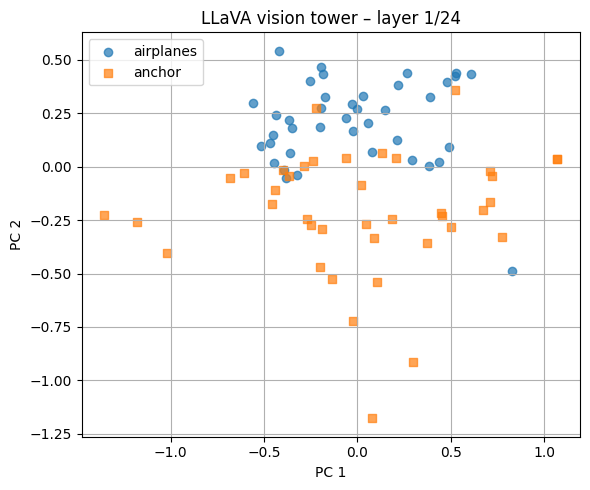

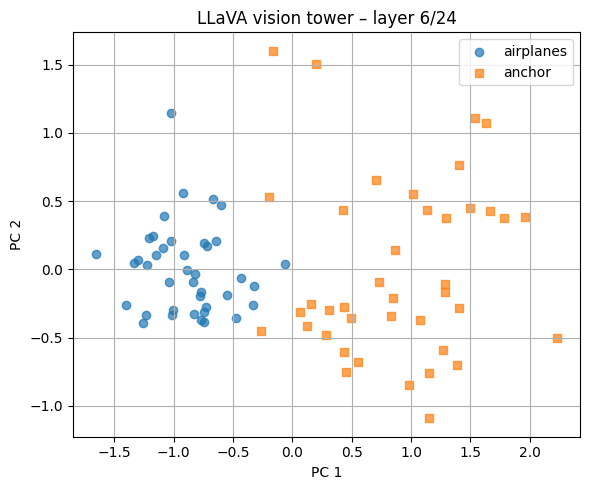

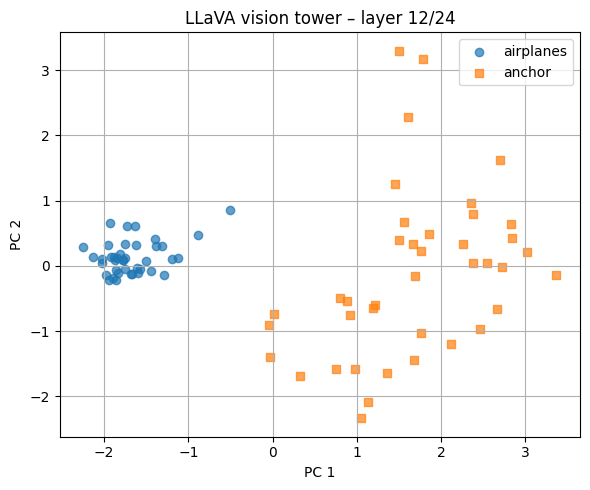

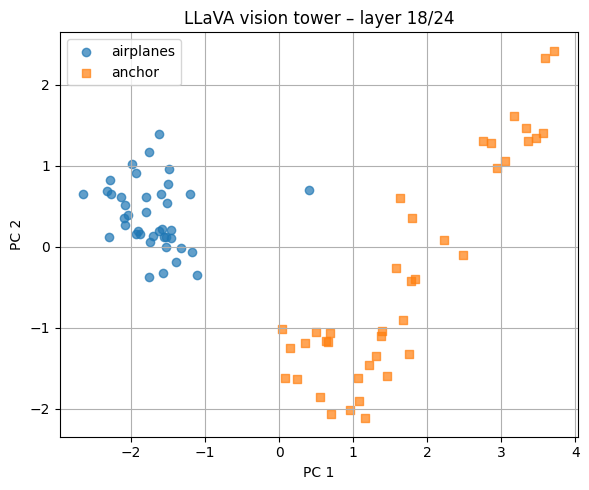

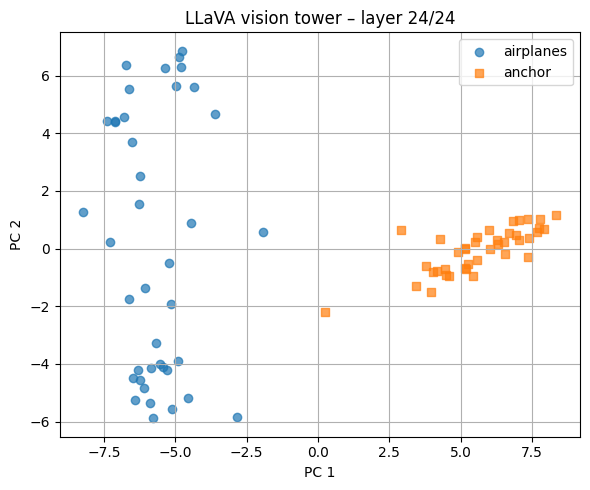

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from torchvision.datasets import Caltech101
from transformers import AutoProcessor, LlavaForConditionalGeneration

class PCAPlotter():
  def __init__(
      self,
      data_dir,
      class_a,
      class_b,
      samples_per_class,
      batch_size,
  ):
    self.data_dir = data_dir
    self.class_a = class_a
    self.class_b = class_b
    self.samples_per_class = samples_per_class
    self.batch_size = batch_size
    self.llava_model_name = "llava-hf/llava-1.5-7b-hf"
    self.device = "cuda" if torch.cuda.is_available() else "cpu"
    self.dataset = Caltech101(root=self.data_dir, download=True)

  def _collect_labels(self):
      class_names = list(self.dataset.categories)
      if self.class_a not in class_names or self.class_b not in class_names:
          raise ValueError(
              f"class_a and class_b must be valid Caltech101 classes. "
              f"Got {self.class_a}, {self.class_b}. Example classes: {class_names[:10]}"
          )
      idx_a = class_names.index(self.class_a)
      idx_b = class_names.index(self.class_b)
      images = []
      labels = []
      count_a = 0
      count_b = 0
      for img, target in self.dataset:
          target = int(target)
          if target == idx_a and count_a < self.samples_per_class:
              images.append(img)
              labels.append(0)
              count_a += 1
          elif target == idx_b and count_b < self.samples_per_class:
              images.append(img)
              labels.append(1)
              count_b += 1
          if count_a >= self.samples_per_class and count_b >= self.samples_per_class:
              break
      labels = np.array(labels)
      print(
          f"Collected {len(labels)} images: "
          f"{count_a} of {self.class_a}, {count_b} of {self.class_b}"
      )
      return images, labels

  def _plot_features_by_layer(self, layer_ids, features_by_layer, labels, num_layers):
      for l in layer_ids:
        features_by_layer[l] = torch.cat(features_by_layer[l], dim=0).numpy()
      print("Feature shapes per layer:")
      for l in layer_ids:
          print(f"  Layer {l}: {features_by_layer[l].shape}")
      for l in layer_ids:
          X = features_by_layer[l]
          pca = PCA(n_components=2)
          X_2d = pca.fit_transform(X)
          plt.figure(figsize=(6, 5))
          for label_val, name, marker in zip(
              [0, 1], [self.class_a, self.class_b], ["o", "s"]
          ):
              idx = labels == label_val
              plt.scatter(
                  X_2d[idx, 0],
                  X_2d[idx, 1],
                  alpha=0.7,
                  label=name,
                  marker=marker,
              )
          plt.xlabel("PC 1")
          plt.ylabel("PC 2")
          plt.title(f"LLaVA vision tower – layer {l}/{num_layers}")
          plt.legend()
          plt.grid(True)
          plt.tight_layout()
          plt.show()

  def plot(self):
    images, labels = self._collect_labels()
    processor = AutoProcessor.from_pretrained(self.llava_model_name)
    model = LlavaForConditionalGeneration.from_pretrained(
        self.llava_model_name,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        low_cpu_mem_usage=True,
    ).to(self.device)
    model.eval()
    vision_tower = model.vision_tower.to(self.device)
    vision_tower.eval()
    num_layers = vision_tower.config.num_hidden_layers
    layer_ids = np.linspace(1, num_layers, 5, dtype=int).tolist()
    features_by_layer = {l: [] for l in layer_ids}
    printed_dims = False
    with torch.no_grad():
        for start in range(0, len(images), self.batch_size):
            batch_imgs = images[start:start + self.batch_size]
            image_inputs = processor.image_processor(
                images=batch_imgs,
                return_tensors="pt",
            )
            pixel_values = image_inputs["pixel_values"].to(self.device)
            outputs = vision_tower(
                pixel_values=pixel_values,
                output_hidden_states=True,
            )
            hidden_states = outputs.hidden_states  # [embeds, layer1, ..., layerN]
            for l in layer_ids:
                hs = hidden_states[l]
                cls_tokens = hs[:, 0, :].cpu() # we take the CLS token ~= summary of the image
                if not printed_dims:
                    B, S, D = hs.shape
                    print(f"Layer {l}: hidden state shape (batch, seq_len, dim) = ({B}, {S}, {D})")
                    print(f"Layer {l}: CLS embedding shape (batch, dim) = {cls_tokens.shape}")
                    printed_dims = True
                features_by_layer[l].append(cls_tokens)
    self._plot_features_by_layer(layer_ids, features_by_layer, labels, num_layers)


if __name__ == "__main__":
    pca_plotter = PCAPlotter(
        data_dir="./data",
        class_a="airplanes",
        class_b="anchor",
        samples_per_class=40,
        batch_size=8,
    )
    pca_plotter.plot()
